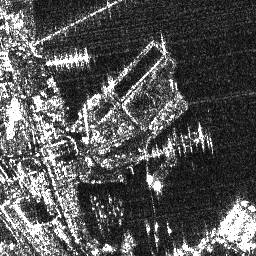

In [20]:
import pandas as pd
from PIL import Image

# 打开 TIFF 文件
img = Image.open('../dataset/AIR-SARShip-1.0/data_spilt/images/SARShip-1.0-1_r00000_c00768.tiff')
img.show()  # 显示图像


In [16]:
import rasterio

# 打开 TIFF 文件
with rasterio.open('../dataset/AIR-SARShip-1.0/data_spilt/images/SARShip-1.0-1_r02432_c02432.tiff') as dataset:
    # 获取仿射变换矩阵
    transform = dataset.transform
    print("Transform:", transform)
    
    # 获取地理坐标参考系统（CRS）
    crs = dataset.crs
    print("CRS:", crs)

Transform: | 3.00, 0.00, 398197.03|
| 0.00,-3.00, 117781.13|
| 0.00, 0.00, 1.00|
CRS: PROJCS["Projection Name = UTMUnits = Meter",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257164354493]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",44.1113085019463],PARAMETER["central_meridian",8.43281963517969],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",400000],PARAMETER["false_northing",100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [7]:
import rasterio

# 打开 TIFF 文件
with rasterio.open('SARShip-1.0-2.tiff') as dataset:
    # 获取仿射变换矩阵
    transform = dataset.transform
    print("Transform:", transform)
    
    # 获取地理坐标参考系统（CRS）
    crs = dataset.crs
    print("CRS:", crs)

Transform: | 1.00, 0.00, 395192.74|
| 0.00,-1.00, 103433.81|
| 0.00, 0.00, 1.00|
CRS: PROJCS["Projection Name = UTMUnits = Meter",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257164354493]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",30.1750794778181],PARAMETER["central_meridian",114.404640526027],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",400000],PARAMETER["false_northing",100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


CRS: PROJCS["Projection Name = UTMUnits = Meter",

GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257164354493]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],

PROJECTION["Transverse_Mercator"],

PARAMETER["latitude_of_origin",30.1750794778181],

PARAMETER["central_meridian",114.404640526027],

PARAMETER["scale_factor",0.9996],

PARAMETER["false_easting",400000],

PARAMETER["false_northing",100000],

UNIT["metre",1,AUTHORITY["EPSG","9001"]],

AXIS["Easting",EAST],

AXIS["Northing",NORTH]]

In [ ]:
import rasterio
from pyproj import Proj, transform

# 打开图像文件
dataset = rasterio.open("../dataset/AIR-SARShip-1.0/SARShip-1.0-1/SARShip-1.0-1.tiff")

# 获取仿射变换和CRS
transform = dataset.transform
crs = dataset.crs
print("CRS:", crs)
# 定义 WGS84 的投影（经纬度坐标系）
wgs84 = Proj(init='epsg:4326')  # WGS84 (经纬度坐标系)

# 要转换的像素位置 (假设我们想转换像素 (col, row) = (256, 256))
col, row = 256, 256

# 使用仿射变换将像素坐标转换为地图坐标（例如 UTM 坐标系）
x, y = transform * (col, row)

# 定义输入坐标系的投影（如果影像使用 UTM）
utm = Proj(init=crs.to_string())

# 将地图坐标转换为 WGS84 经纬度
longitude, latitude = transform(utm, wgs84, x, y)

# 输出经纬度
print(f"Longitude: {longitude}, Latitude: {latitude}")


Longitude: 3.517356708453969, Latitude: 43.10518837061141


/home/kapi/miniconda3/envs/TDL/lib/python3.10/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
Warning 1: The definition of geographic CRS EPSG:4326 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.
/tmp/ipykernel_1868/109337727.py:25: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  longitude, latitude = transform(proj, w

Warning 1: The definition of geographic CRS EPSG:4326 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/kapi/miniconda3/envs/TDL/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import